In [1]:
!pip install pulp matplotlib ortools


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# VISUALIZATION
# Takes the result of the optimization model and draws a 2D picture of the truck with the boxes loaded
# Positions come from optimization model,

import matplotlib.pyplot as plt
def plot_solution(N, L, solution):
    # fig = whole figure
    # ax = coordinate system where teh rectangles go
    fig, ax = plt.subplots(figsize=(12, 4))

    # Loop through the containers from the solution
    for i, box in enumerate(solution):
        # create a rectangle per container
        rect = plt.Rectangle(
            (box["x"], box["y"]), # bottom left corner
            box["h"], box["w"],# height (truck length), width
            edgecolor='black'
        )
        ax.add_patch(rect)
        # add box number
        ax.text(
            box["x"] + box["h"]/2,
            box["y"] + box["w"]/2,
            str(i), # starts from 0
            ha='center', va='center'
        )

    ax.set_xlim(0, L)
    ax.set_ylim(0, 250)
    ax.set_title(f"N={N}, Length={L:.2f} cm")
    plt.gca().invert_yaxis()
    plt.show()

In [9]:


# CP-SAT from Google OR-Tools
from ortools.sat.python import cp_model

# Solver function
def solve_packing_cpsat(N, time_limit=30):

    # 1. First the model is created (with this model we define the problem)
    model = cp_model.CpModel()

    # 2. Dimensions (scaled to integers to avoid floats)
    # CP-SAT only works with integers, but the dimensions include decimals (56.5 cm) so I make them into integers 10*56.5 = 565 then divide it back to floats before returning answer
    SCALE = 10

    # Each container have two possible orientations:
    # Normal orientation
    W1 = int(56.5 * SCALE)   # width
    L1 = int(135 * SCALE)    # length

    # Rotated orientation (swap width and length)
    W2 = int(135 * SCALE)
    L2 = int(56.5 * SCALE)

    TRUCK_WIDTH = int(250*SCALE) # Truck width

    #3.  Create Variables, these are the unknowns which we want to solve
    # Horizontal positions of container i along truck length
    x = [model.NewIntVar(0, 20000, f"x_{i}") for i in range(N)]

    # vertical positions of container i across truck width
    y = [model.NewIntVar(0, TRUCK_WIDTH, f"y_{i}") for i in range(N)]

    # rotation variable 0 = normal, 1 = rotated
    r = [model.NewBoolVar(f"r_{i}") for i in range(N)]

    # These will store the actual width and height AFTER rotation
    w = []
    h = []

    # 4. Handeling Rotation
    for i in range(N):

        # Create variables for width and height of each container
        wi = model.NewIntVar(min(W1, W2), max(W1, W2), f"w_{i}")
        hi = model.NewIntVar(min(L1, L2), max(L1, L2), f"h_{i}")

        # If not rotated --> original dimensions
        model.Add(wi == W1).OnlyEnforceIf(r[i].Not())
        model.Add(hi == L1).OnlyEnforceIf(r[i].Not())

        # If rotated --> swapped dimenstions
        model.Add(wi == W2).OnlyEnforceIf(r[i])
        model.Add(hi == L2).OnlyEnforceIf(r[i])

        # Store them
        w.append(wi)
        h.append(hi)

    # 5. Objective variable, this is what we want to minimize

    # L = how much length of the truck is used
    L = model.NewIntVar(0, 20000, "L")

    # 6. Boundary constraints, so the boxes stay inside the truck
    for i in range(N):

        # Stay within truck width
        # y + width <= TRUCK WIDTH
        model.Add(y[i] + w[i] <= TRUCK_WIDTH)

        # Stay within used length
        # x + height <= L
        model.Add(x[i] + h[i] <= L)

    # 7. No-overlap Constraints, MUST ensure containers do not overlap each other
    x_intervals = []
    y_intervals = []

    for i in range(N):

        # Define end positions
        x_end = model.NewIntVar(0, 20000, f"x_end_{i}")
        y_end = model.NewIntVar(0, TRUCK_WIDTH, f"y_end_{i}")

        # Link end = start + size
        model.Add(x_end == x[i] + h[i])
        model.Add(y_end == y[i] + w[i])


        xi = model.NewIntervalVar(x[i], h[i], x_end, f"x_int_{i}")
        yi = model.NewIntervalVar(y[i], w[i], y_end, f"y_int_{i}")

        x_intervals.append(xi)
        y_intervals.append(yi)

    # This constraint ensures that no rectangle can overlap each other in the 2D space
    model.AddNoOverlap2D(x_intervals, y_intervals)

    # 8. Objective Function, to minimize the length of the truck
    model.Minimize(L)

    # 9. First Solve, then find the optimal length
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit
    solver.parameters.num_search_workers = 8 # Parallel solving

    status = solver.Solve(model)

    # If no optimal or feasable solution was found (feasable = unknown if optimal)
    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return None, None

    solution = []
    # Positions of the boxes
    for i in range(N):
        solution.append({
            #(x,y) of the bottom left corner of the box
            "x": solver.Value(x[i]) / SCALE,
            "y": solver.Value(y[i]) / SCALE,
            #(width and hight)
            "w": solver.Value(w[i]) / SCALE,
            "h": solver.Value(h[i]) / SCALE, # height = length direction
        })

    return solver.Value(L) / SCALE, solution

Optimal Length: 1328.0


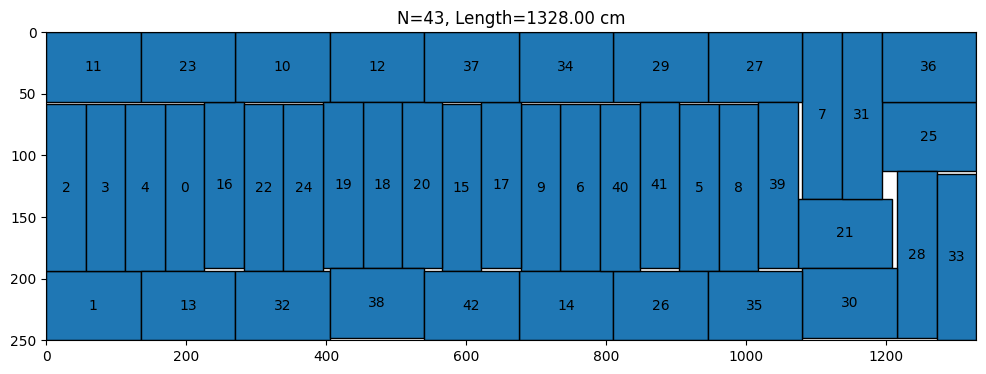

In [5]:

N = 43 # OBS zero idexed so boxes are from 0--> N-1
L, solution = solve_packing_cpsat(N) # 30 s time limit

print("Optimal Length:", L)
plot_solution(N, L, solution)

Optimal Length: 1328.0


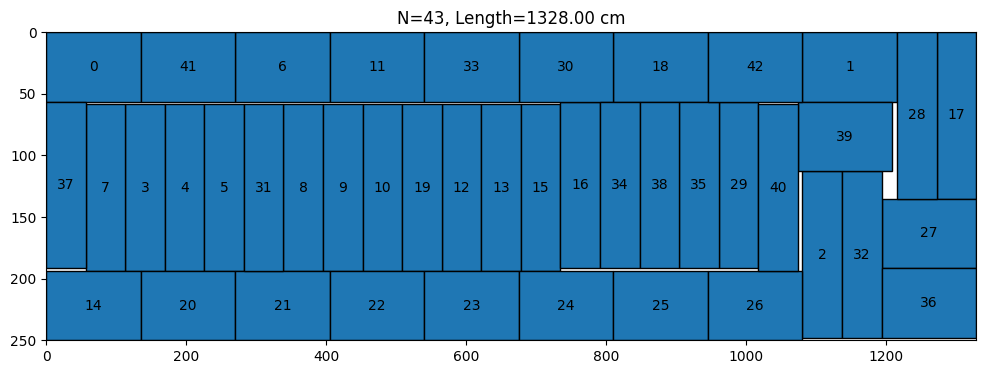

In [10]:
N = 43 # OBS zero idexed so boxes are from 0--> N-1
L, solution = solve_packing_cpsat(N, time_limit=200) # 200 s time limit

print("Optimal Length:", L)
plot_solution(N, L, solution)

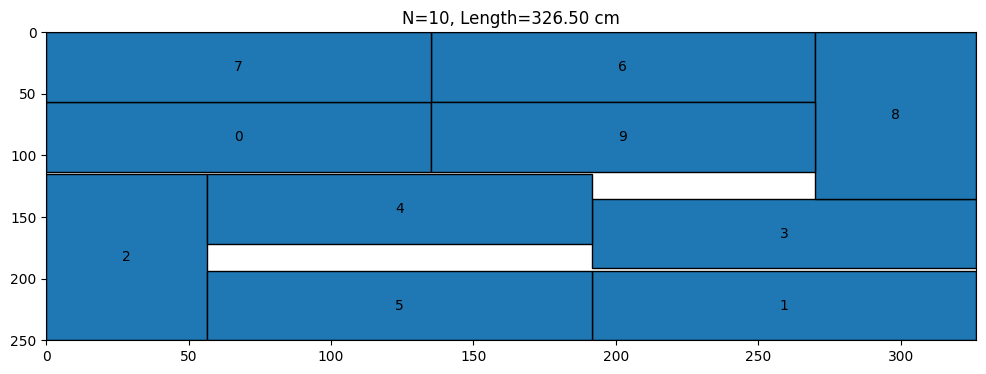

In [33]:
# 10 boxes
N = 10 # OBS zero idexed so boxes are from 0--> N-1
L, solution = solve_packing_cpsat(N, time_limit=20) # 60 s time limit

plot_solution(N, L, solution)

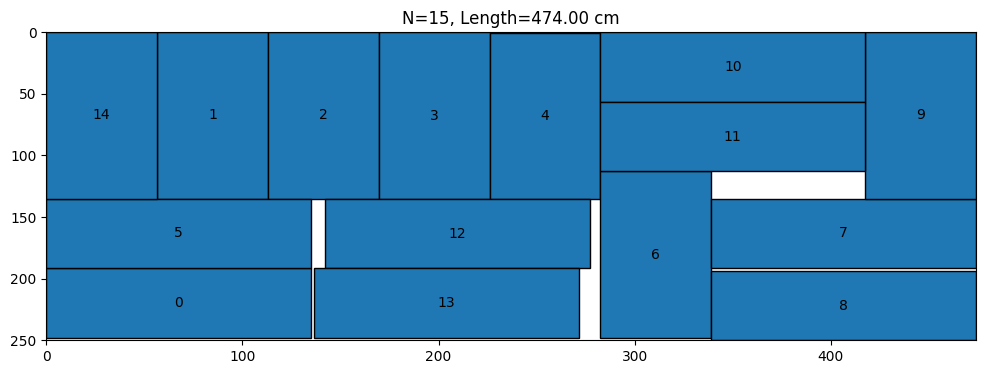

In [28]:
# 15 boxes
N = 15 # OBS zero idexed so boxes are from 0--> N-1
L, solution = solve_packing_cpsat(N, time_limit=60) # 60 s time limit

plot_solution(N, L, solution)

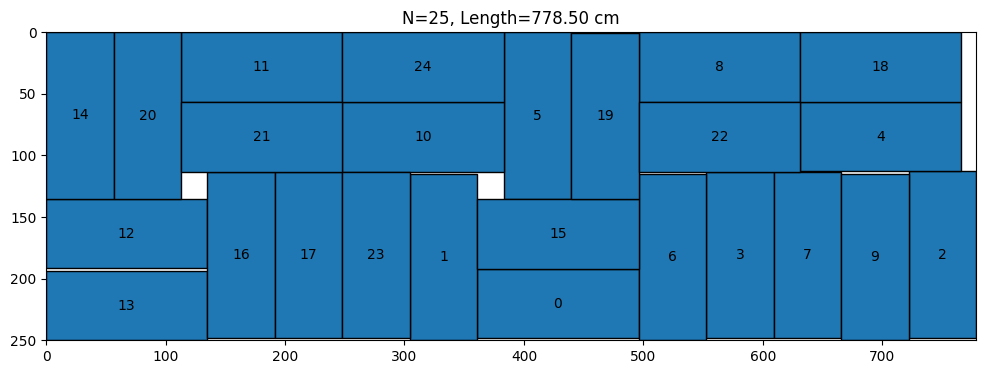

In [29]:
# 25 boxes
N = 25 # OBS zero idexed so boxes are from 0--> N-1
L, solution = solve_packing_cpsat(N, time_limit=60) # 60 s time limit

plot_solution(N, L, solution)

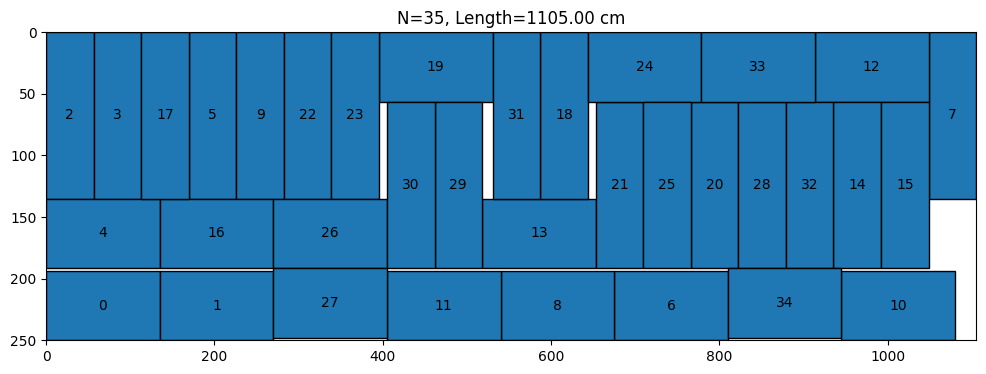

In [30]:
# 35 boxes
N = 35 # OBS zero idexed so boxes are from 0--> N-1
L, solution = solve_packing_cpsat(N, time_limit=60) # 60 s time limit

plot_solution(N, L, solution)

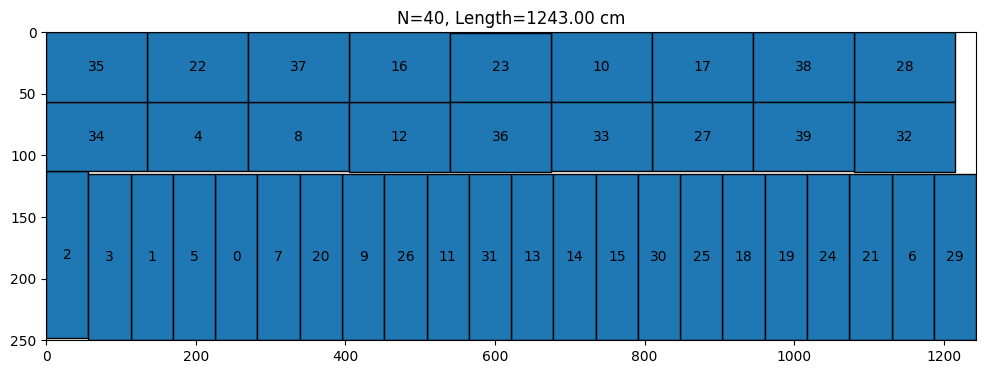

In [31]:
# 40 boxes
N = 40 # OBS zero idexed so boxes are from 0--> N-1
L, solution = solve_packing_cpsat(N, time_limit=60) # 60 s time limit

plot_solution(N, L, solution)

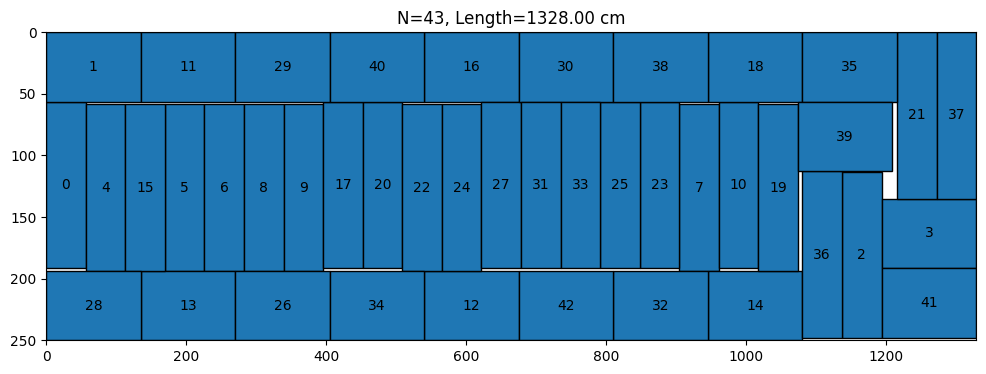

In [32]:

N = 43 # OBS zero idexed so boxes are from 0--> N-1
L, solution = solve_packing_cpsat(N, time_limit=1000)

plot_solution(N, L, solution)